# Cardiography EDA

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path('/content/Cardiotocographic.csv')  # Place cardiographic.csv alongside this notebook
df = pd.read_csv(data_path)
df.columns = [c.strip().replace(' ', '_').replace('-', '_') for c in df.columns]
for col in df.columns:
    if df[col].dtype == object:
        conv = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
        if conv.notna().mean() > 0.5:
            df[col] = conv
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


## Missing Values & Imputation

In [13]:
missing = df.isna().sum().sort_values(ascending=False)
display(missing.to_frame('Missing').assign(Missing=lambda x: x['Missing']/len(df)*100))
df_imputed = df.copy()
for col in numeric_cols:
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].median())
for col in categorical_cols:
    if df_imputed[col].isna().any():
        m = df_imputed[col].mode(dropna=True)
        df_imputed[col] = df_imputed[col].fillna(m.iloc[0] if len(m) else None)
df = df_imputed


,Missing
LB,0.987770
DS,0.987770
MLTV,0.987770
Width,0.987770
Tendency,0.987770
DP,0.987770
NSP,0.987770
AC,0.940734
FM,0.000000
UC,0.000000


## Outliers (Winsorization at 5th/95th percentile)

In [14]:
df_clean = df.copy()
for col in numeric_cols:
    s = df_clean[col]
    if s.notna().sum()>0:
        df_clean[col] = s.clip(s.quantile(0.05), s.quantile(0.95))
df = df_clean
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LB,2126.0,133.371211,8.882701,119.0,126.000000,133.000000,140.000000,149.000000
AC,2126.0,0.003054,0.003560,0.0,0.000000,0.001634,0.005606,0.011059
FM,2126.0,0.003520,0.007512,0.0,0.000000,0.000000,0.002567,0.029395
UC,2126.0,0.004308,0.002844,0.0,0.001851,0.004484,0.006536,0.009277
DL,2126.0,0.001795,0.002670,0.0,0.000000,0.000000,0.003289,0.008412
DS,2126.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
DP,2126.0,0.000117,0.000392,0.0,0.000000,0.000000,0.000000,0.001564
ASTV,2126.0,46.961986,16.656321,21.0,32.000000,49.000000,61.000000,75.000000
MSTV,2126.0,1.299399,0.754105,0.3,0.700000,1.200000,1.700000,3.000000
ALTV,2126.0,9.467948,16.801511,0.0,0.000000,0.000000,11.000000,58.000000


## Distributions

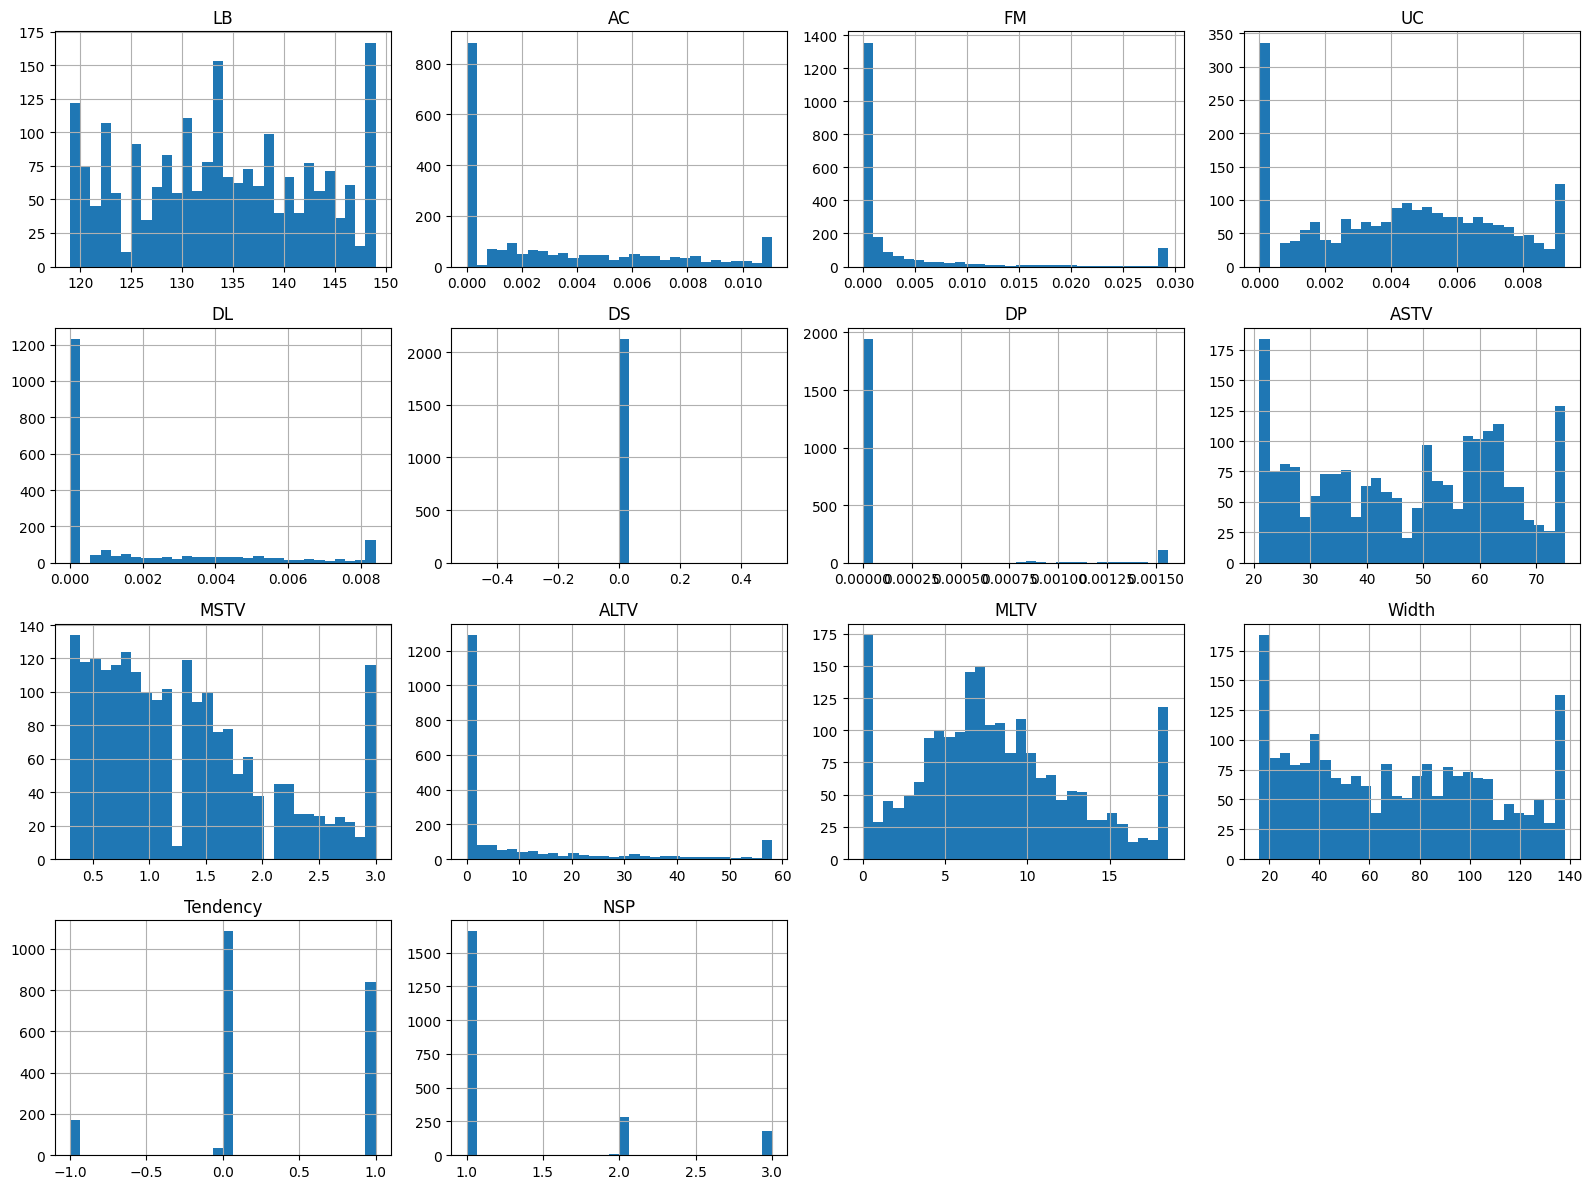

In [15]:
df[numeric_cols].hist(bins=30, figsize=(16,12)); plt.tight_layout(); plt.show()

## Boxplots

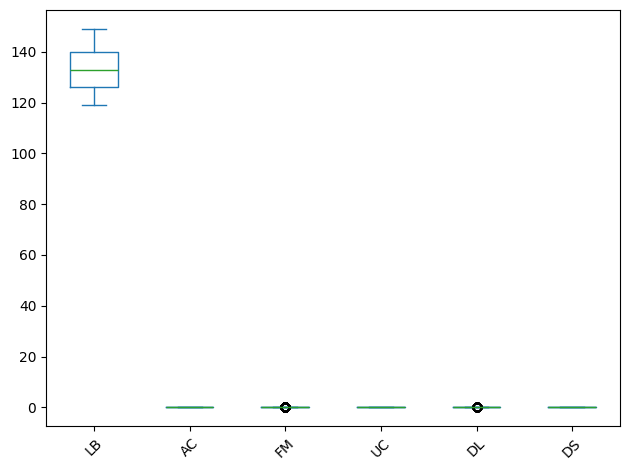

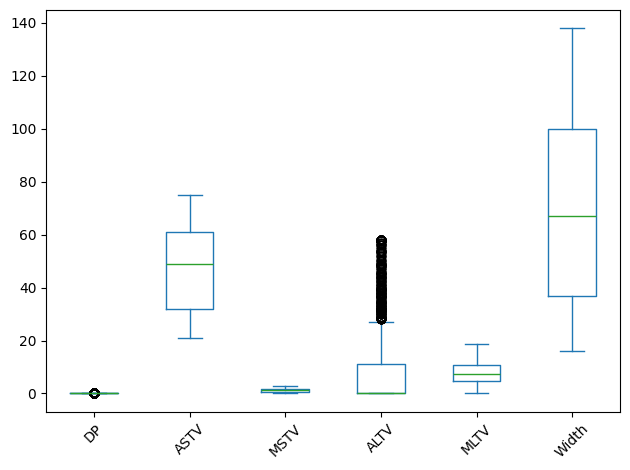

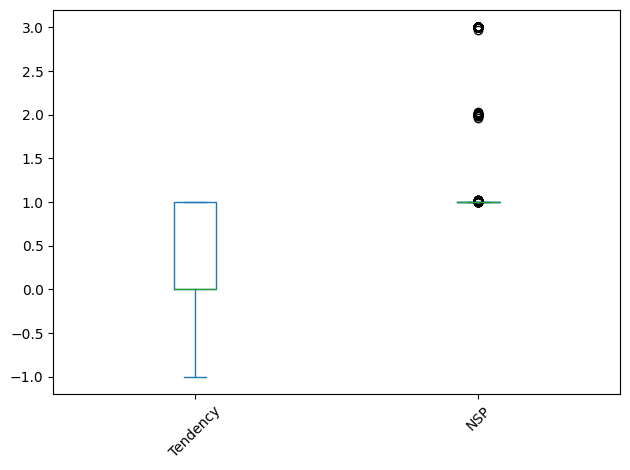

In [16]:
for i in range(0, len(numeric_cols), 6):
    ax = df[numeric_cols[i:i+6]].plot(kind='box', vert=True, rot=45)
    plt.tight_layout(); plt.show()


## Categorical Frequencies

In [17]:
for col in categorical_cols:
    vc = df[col].value_counts().head(15)
    ax = vc.plot(kind='bar', title=f'Frequency of {col} (Top 15)')
    plt.xlabel(col); plt.ylabel('Count'); plt.tight_layout(); plt.show()


## Correlations

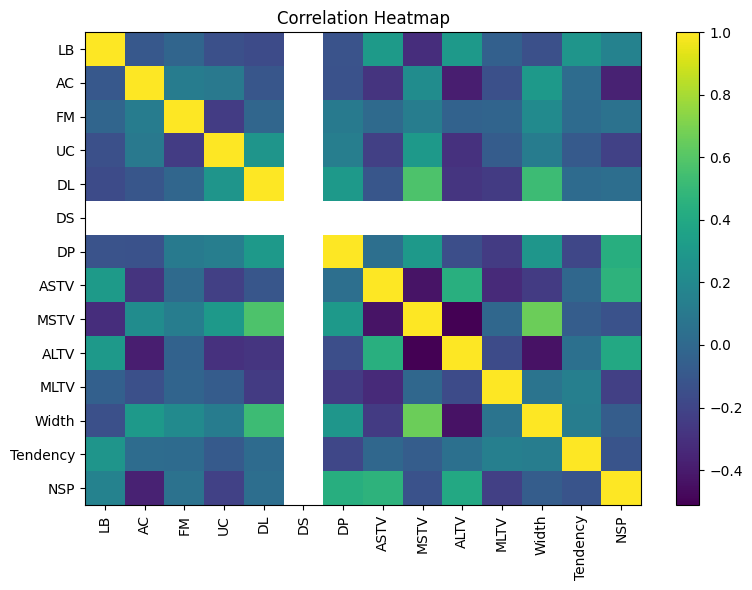

,,0
MSTV,Width,0.661009
DL,MSTV,0.576028
Width,DL,0.523690
MSTV,ALTV,0.511507
NSP,ASTV,0.462909
ASTV,ALTV,0.440559
Width,ALTV,0.438368
NSP,DP,0.436176
MSTV,ASTV,0.430979
ALTV,NSP,0.398261


In [18]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
plt.imshow(corr, aspect='auto')
plt.colorbar(); plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title('Correlation Heatmap'); plt.tight_layout(); plt.show()
corr.abs().unstack().sort_values(ascending=False).drop_duplicates()[1:11]

## Pairwise Scatter (Top-variance columns)

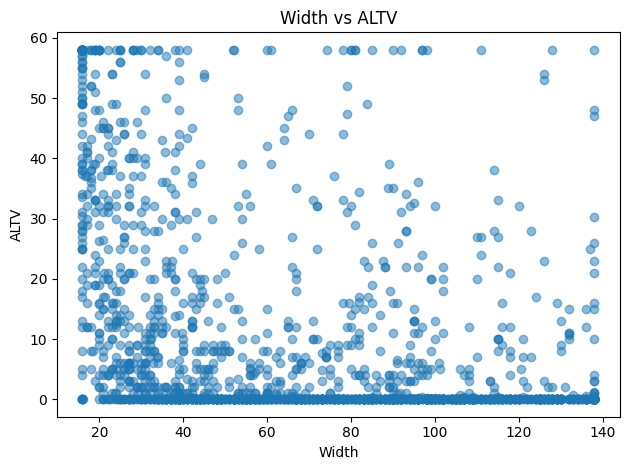

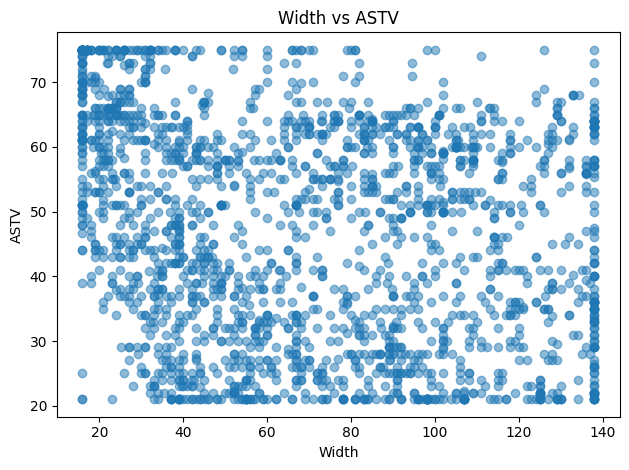

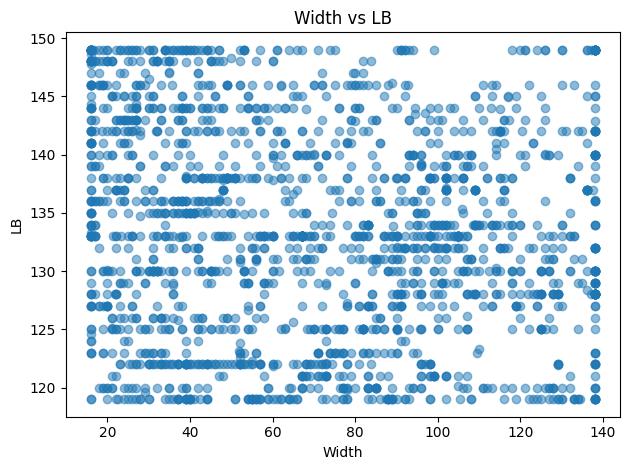

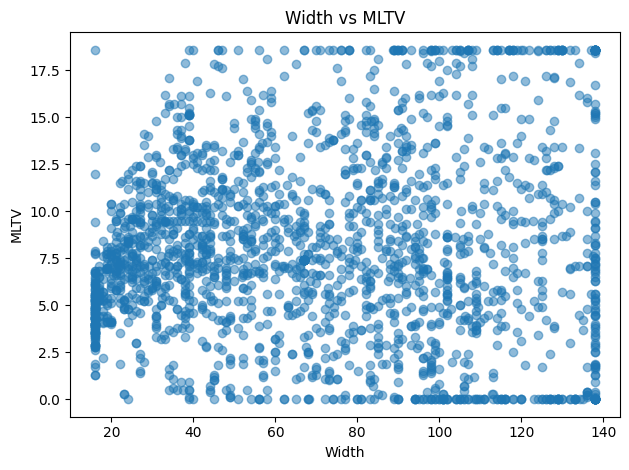

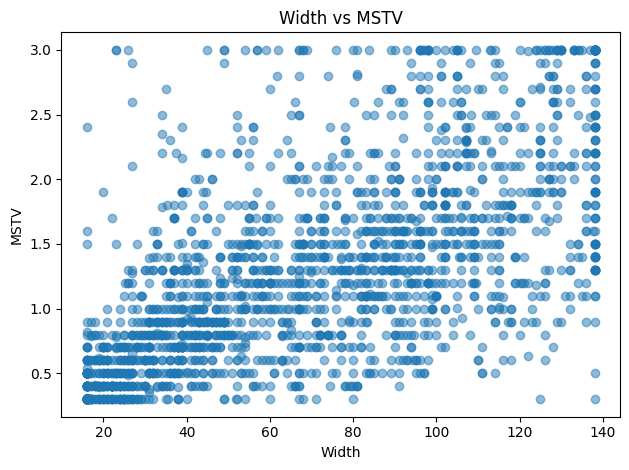

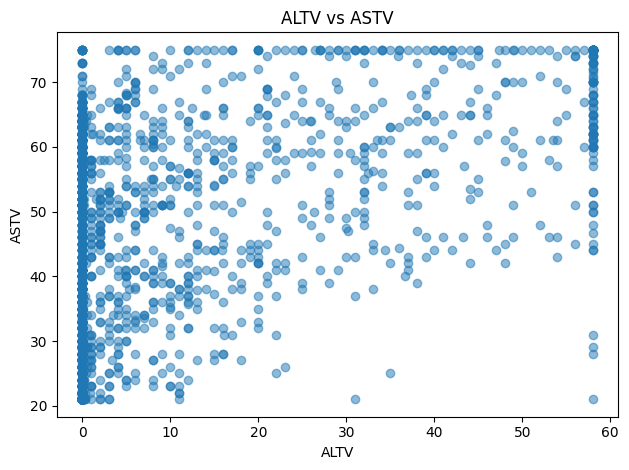

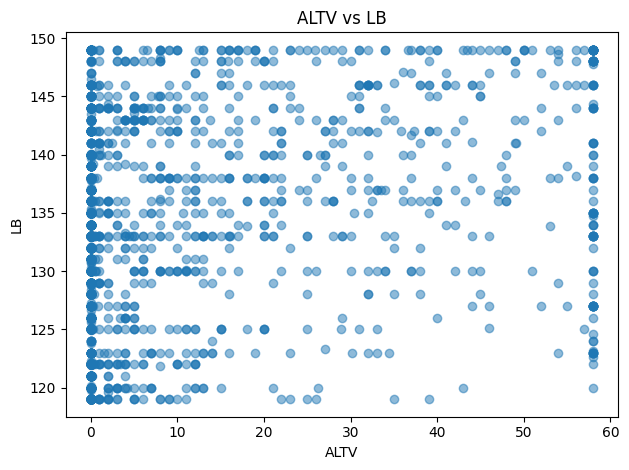

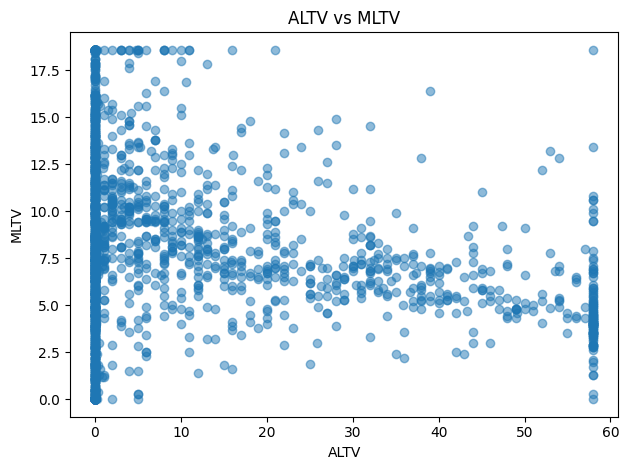

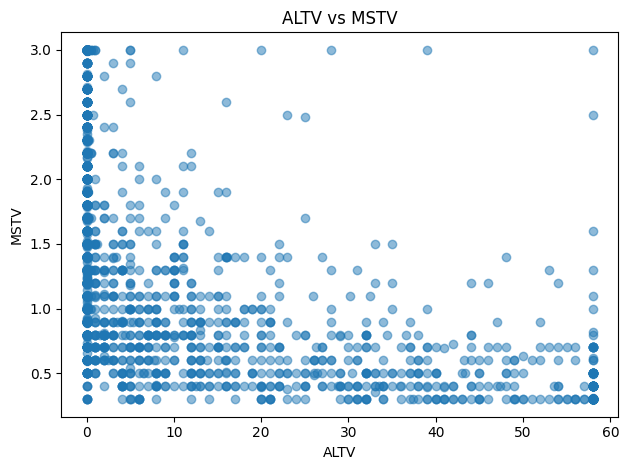

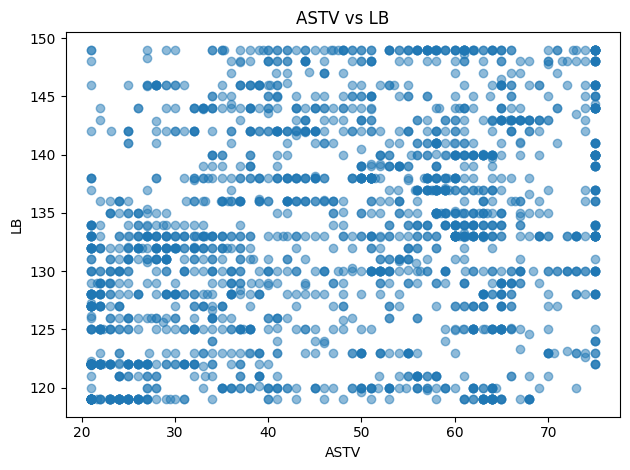

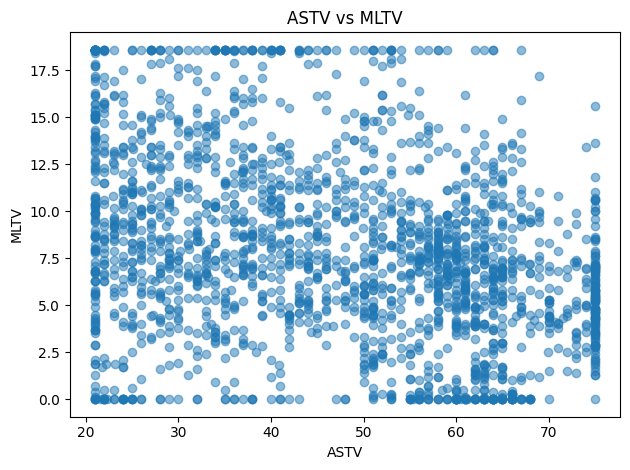

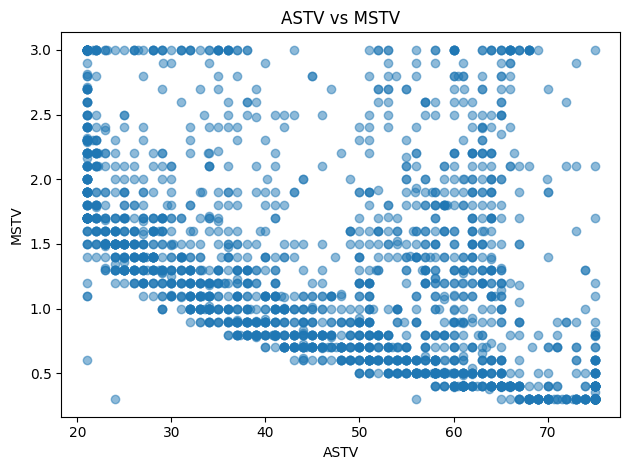

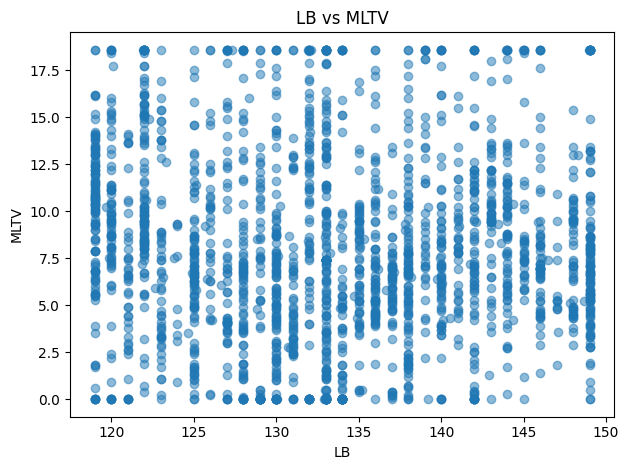

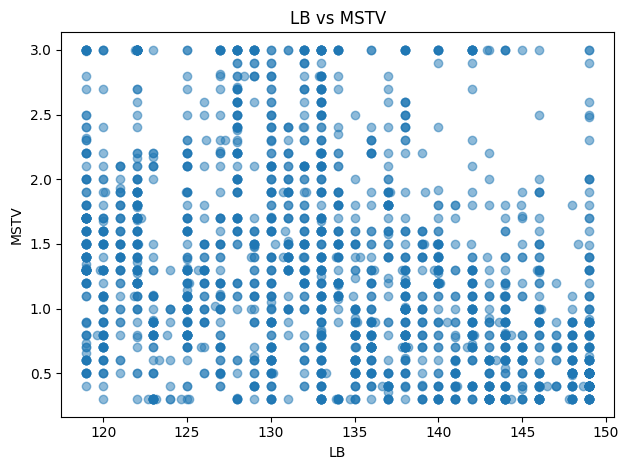

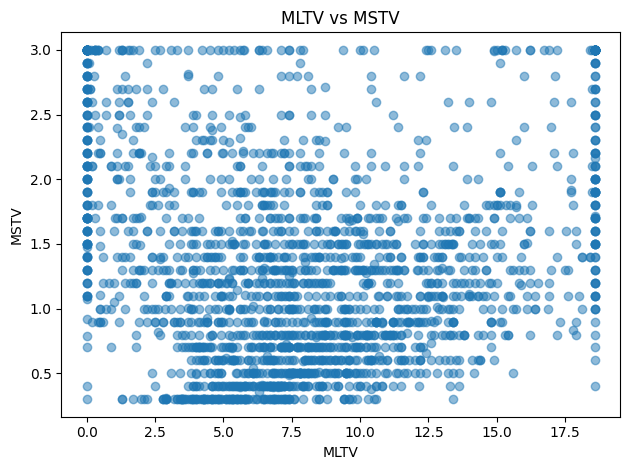

In [19]:
var_series = df[numeric_cols].var().sort_values(ascending=False)
top_vars = var_series.head(min(6, len(var_series))).index.tolist()
for i, x in enumerate(top_vars):
    for y in top_vars[i+1:]:
        plt.figure(); plt.scatter(df[x], df[y], alpha=0.5)
        plt.xlabel(x); plt.ylabel(y); plt.title(f'{x} vs {y}')
        plt.tight_layout(); plt.show()


## Save Cleaned Data

In [20]:
df.to_csv('cardiographic_clean.csv', index=False)
print('Saved: cardiographic_clean.csv')

Saved: cardiographic_clean.csv
